# EDA - SINAN Esquistossomose (base processada)

Base: `data/processed/sinan_esqu_processed_with_dt_notific.parquet`.

Objetivo: explorar qualidade, nulos, distribuicoes e padrões relevantes para analise e modelagem.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")

In [2]:
data_path = Path("../data/processed/sinan_esq_processed_with_dt_notific.parquet")
if not data_path.exists():
    raise FileNotFoundError(f"Arquivo nao encontrado: {data_path.resolve()}")

df = pd.read_parquet(data_path)
print(f"Linhas: {len(df):,} | Colunas: {df.shape[1]}")

df.head()

Linhas: 64,068 | Colunas: 17


,DT_NOTIFIC,ID_MUNICIP,ID_UNIDADE,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,TRATAM,FORMA,COUFINF,DOENCA_TRA,EVOLUCAO,AN_QUALI,IDADE_PROCESSADA,delay_notificacao_dias,tempo_encerramento_dias
0,2007-10-30,260765,2429020,F,5,1,2,26,1,1,26,2,1,1,24.0,111,57.0
1,2007-10-08,260500,2631504,M,6,4,3,26,3,1,26,2,1,1,23.0,61,1.0
2,2007-10-18,260420,2712741,F,5,1,1,26,1,1,26,2,1,1,26.0,64,0.0
3,2007-10-09,260420,2712741,M,6,4,1,26,1,1,26,2,1,1,9.0,60,0.0
4,2007-10-02,260420,2712741,F,5,4,1,26,1,1,26,2,1,1,34.0,5,0.0


In [3]:
dtype_counts = df.dtypes.value_counts().rename("qtd")
display(dtype_counts)

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nunique": df.nunique(dropna=True),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
})

display(overview.sort_values("missing_pct", ascending=False).head(20))

string[python]    13
float64            2
datetime64[ns]     1
int64              1
Name: qtd, dtype: int64

,dtype,nunique,missing,missing_pct
tempo_encerramento_dias,float64,169,6530,10.19
DT_NOTIFIC,datetime64[ns],5344,0,0.00
ID_MUNICIP,string,1767,0,0.00
CS_SEXO,string,2,0,0.00
ID_UNIDADE,string,7060,0,0.00
CS_RACA,string,5,0,0.00
CS_ESCOL_N,string,10,0,0.00
SG_UF,string,26,0,0.00
CS_GESTANT,string,6,0,0.00
TRATAM,string,4,0,0.00


,missing_pct
tempo_encerramento_dias,10.192296


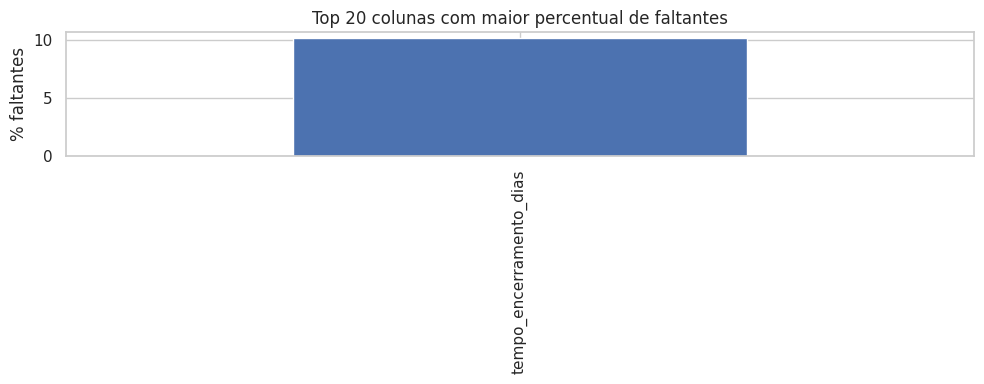

In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_tbl = missing_pct[missing_pct > 0].to_frame("missing_pct")

display(missing_tbl.head(30))

if not missing_tbl.empty:
    ax = missing_tbl.head(20).plot(kind="bar", figsize=(10, 4), legend=False)
    ax.set_title("Top 20 colunas com maior percentual de faltantes")
    ax.set_ylabel("% faltantes")
    plt.tight_layout()

,contagem
EVOLUCAO,
1,63496
2,457
3,68
4,47


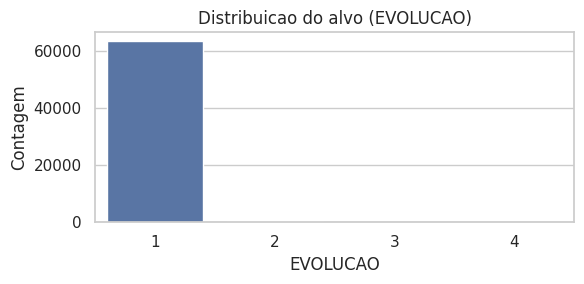

In [5]:
target = "EVOLUCAO"
if target in df.columns:
    target_counts = df[target].astype("string").value_counts(dropna=False)
    display(target_counts.to_frame("contagem"))

    plt.figure(figsize=(6, 3))
    sns.countplot(x=df[target].astype("string"), order=target_counts.index)
    plt.title("Distribuicao do alvo (EVOLUCAO)")
    plt.xlabel("EVOLUCAO")
    plt.ylabel("Contagem")
    plt.tight_layout()
else:
    print("Coluna EVOLUCAO nao encontrada.")

Colunas numericas: 3


,count,mean,std,min,25%,50%,75%,max
IDADE_PROCESSADA,64068.0,32.422664,16.998987,0.0,19.0,31.0,44.0,84.0
delay_notificacao_dias,64068.0,33.160189,37.702221,0.0,1.0,21.0,51.0,159.0
tempo_encerramento_dias,57538.0,30.805242,40.633614,0.0,0.0,12.0,49.0,168.0


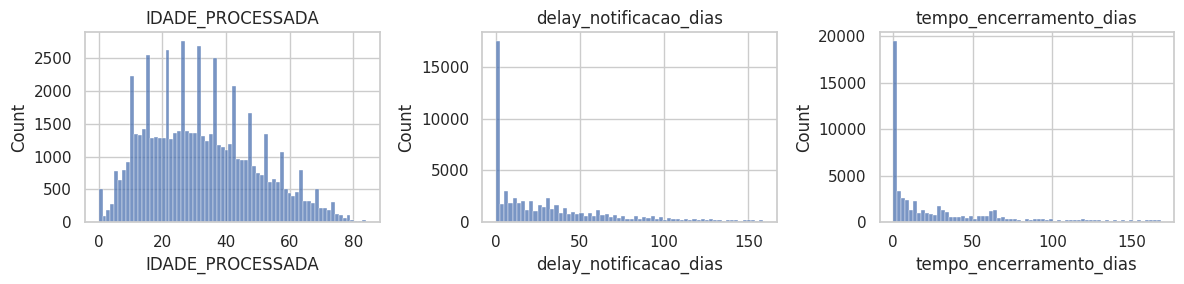

In [6]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print(f"Colunas numericas: {len(num_cols)}")

if num_cols:
    display(df[num_cols].describe().T)

    n_plot = min(6, len(num_cols))
    cols_plot = num_cols[:n_plot]

    fig, axes = plt.subplots(1, n_plot, figsize=(4 * n_plot, 3))
    if n_plot == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_plot):
        sns.histplot(df[col], kde=False, ax=ax)
        ax.set_title(col)
    plt.tight_layout()
else:
    print("Nao ha colunas numericas para descrever.")

Colunas categoricas: 13


,contagem
CS_SEXO,
M,39469
F,24599


,contagem
CS_RACA,
4,40411
1,16553
2,5894
3,846
5,364


,contagem
CS_ESCOL_N,
1,31519
3,9523
2,5875
6,5196
4,3527
5,3523
0,1940
10,1849
8,752


,contagem
FORMA,
1,59271
4,1951
2,1334
5,1059
3,453


,contagem
TRATAM,
1,61272
3,2194
2,600
4,2


,contagem
DOENCA_TRA,
2,58843
1,5225


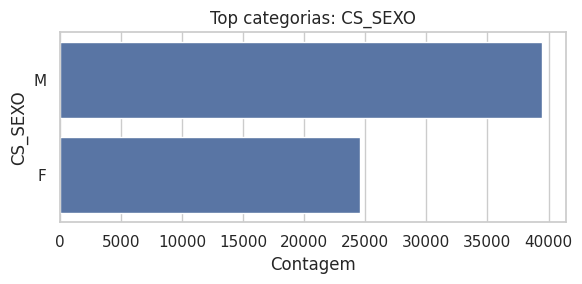

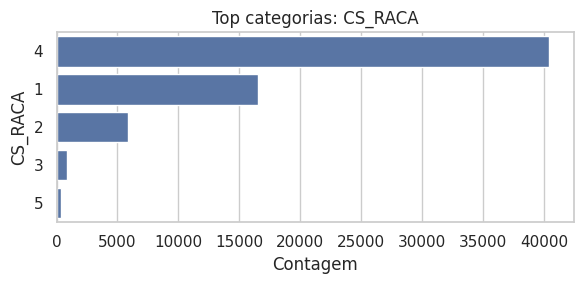

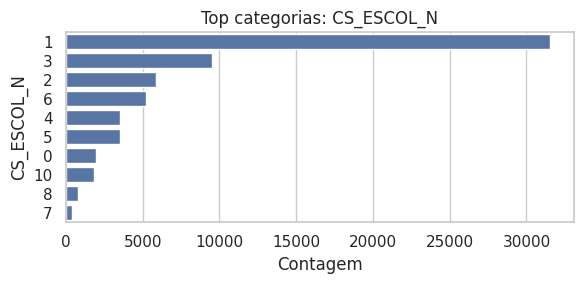

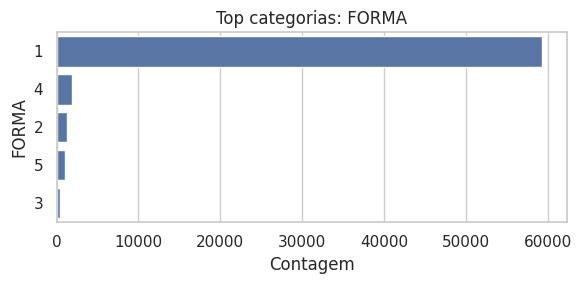

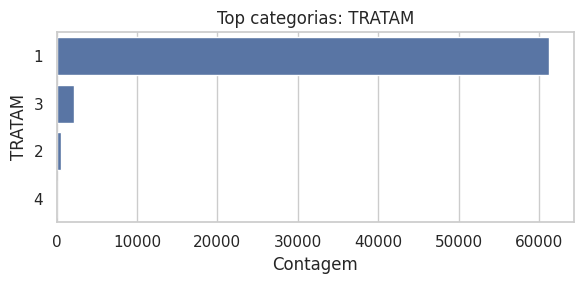

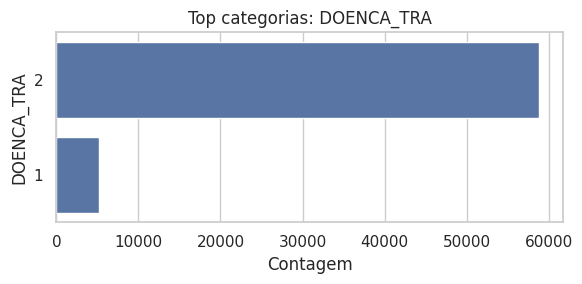

In [7]:
datetime_cols = df.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols and c not in datetime_cols]
print(f"Colunas categoricas: {len(cat_cols)}")

colunas_prioritarias = [
    "CS_SEXO",
    "CS_RACA",
    "CS_ESCOL_N",
    "FORMA",
    "TRATAM",
    "DOENCA_TRA",
]
colunas_plot = [c for c in colunas_prioritarias if c in df.columns]

if not colunas_plot:
    colunas_plot = cat_cols[:4]

for col in colunas_plot:
    vc = df[col].astype("string").value_counts(dropna=False).head(10)
    display(vc.to_frame("contagem"))

    plt.figure(figsize=(6, 3))
    sns.barplot(x=vc.values, y=vc.index)
    plt.title(f"Top categorias: {col}")
    plt.xlabel("Contagem")
    plt.ylabel(col)
    plt.tight_layout()

,count,mean,std,min,25%,50%,75%,max
delay_notificacao_dias,64068.0,33.160189,37.702221,0.0,1.0,21.0,51.0,159.0
tempo_encerramento_dias,57538.0,30.805242,40.633614,0.0,0.0,12.0,49.0,168.0
IDADE_PROCESSADA,64068.0,32.422664,16.998987,0.0,19.0,31.0,44.0,84.0


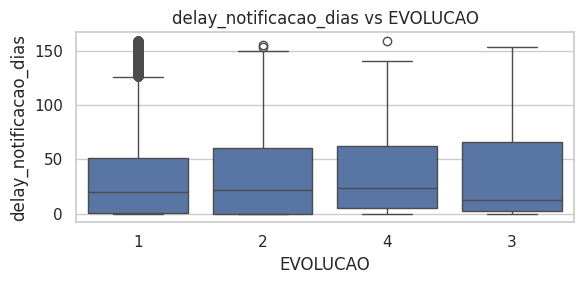

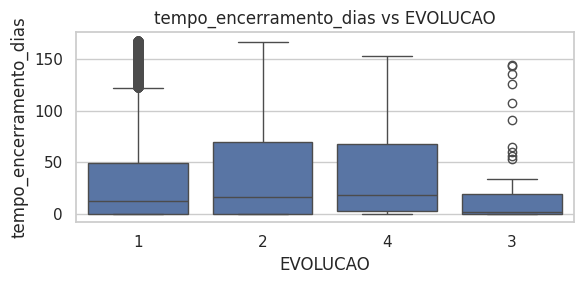

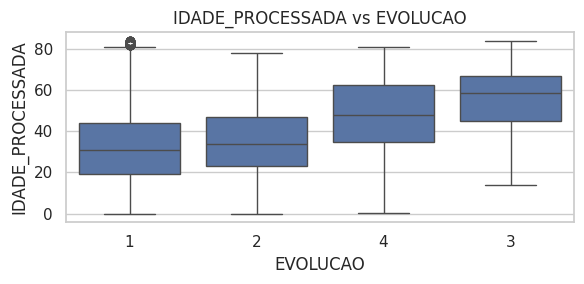

In [8]:
temporal_cols = [
    c
    for c in [
        "delay_notificacao_dias",
        "tempo_encerramento_dias",
        "idade_aprox_no_evento",
        "IDADE_PROCESSADA",
    ]
    if c in df.columns
]

if temporal_cols:
    display(df[temporal_cols].describe().T)

    if target in df.columns:
        for col in temporal_cols:
            plt.figure(figsize=(6, 3))
            sns.boxplot(x=df[target].astype("string"), y=df[col])
            plt.title(f"{col} vs EVOLUCAO")
            plt.xlabel("EVOLUCAO")
            plt.ylabel(col)
            plt.tight_layout()
else:
    print("Nao ha features temporais para analisar.")

## Proximos passos sugeridos

- Revisar colunas com maior taxa de faltantes e decidir tratamento especifico.
- Avaliar balanceamento do alvo `EVOLUCAO`.
- Inspecionar categorias raras e possivel agrupamento.
- Explorar variaveis temporais (delays) por classe para detectar padroes clinicos.